## Module 4: Cancer Hallmark

## Team Members:
*Abhiram Ruthala, Delaney Broderick*

## Project Title:
*The Impact of Immune Response Invasion Genes in individuals with Glioblastoma Across Different Ages*


## Project Goal:
This project seeks to understand how the different genes associated with the immune response invasion cancer hallmark is expressed in individuals with glioblastoma in different age ranges. Using the cancer hallmark of immune invasion response and the associated genes, to see if there is a difference in gene expression in individuals with glioblastoma by age. This can be used to help predict gene expression in certain age groups of those with glioblastoma. 

## Disease Background:

* Cancer Hallmark focus: Immune response evasion
* Overview of hallmark: 
    * Immune Response Evasion: Cancer cells are able to evade immune cells, such as Killer T cells, as they traverse through the human body and continue to develop uncontrollably. Due to this evasion, it makes it harder for the immune system to attack the cancer cells, causing the cancer to prevail for longer with minimal damage. This is a programming of the cancer cell as per its sense of dividing as much as possible.
* Genes associated with hallmark: Immune evasion hallmark includes key oncogenes such as MYC, RAS, and STAT3, and tumor suppressors TP53 and PTEN, which are important for immune suppresion and to avoid detection by key immune cells. 

### Background on Glioblastoma
Glioblastoma is an aggressive type of brain cancer that begins with astrocytes (support nerve cells). Specifically, glial cells - cells in the central and peripheral nervous system - that endure a major mutation/change in the DNA, which then causes them to fail within their own division processes, leading to glioblastoma. Glioblastoma is the most common malignant form of glioma, representing a wide array of glial cell-formed brain cancer.

It's the most common malignant brain tumor in adults and makes up about half of all malignant brain tumors in adults.

Within this group, glioblastoma is classified as a grade 4 glioma (Mayo Clinic, 2024a), the most serious type of glioma. Grade 4 means the tumor grows and spreads quickly into nearby brain tissue, which makes it hard to remove completely.

Symptoms:
Symptoms vary based on where the tumor forms in the brain and may involve seizures, brain swelling, headaches, personality changes, and changes in speech, vision, strength, sensation or balance.

There is no cure for glioblastoma. Treatments such as surgery, radiation and chemotherapy may slow tumor growth, ease symptoms and help people live longer. These are treatment methods that hope to put the cancer in remission by removing the mass, killing off cells that divide fast, and creating environments to where it is harder for such fast-dividing cells to live.

The cause of most glioblastomas is not known. A lot can be pointed to major mutations or transcription factor changes within glial cells that cause them to mishap when dividing as a means to support the brain's nutrition. Poor lifestyle choices compounded over years creates more effective breeding grounds for cancer as mistakes for cells are more prone, the body's immune response drops with time, and cells have accumulated damage from years of previous mistakes as well. 

Risk Factors: 
* Radiation exposure 
* Old age
* Being male
* Inherited syndromes like Lynch Syndrome and Li-Fraumeni syndrome

There are no known mechanisms as to prevent glioblastoma. A lot of general mechanisms point to public health awareness and lifestyle changes as being a deep factor, since that reduces the abilities for cells to drift, make changes, and have unnecessary mutations that would've taken place if not for proper cell management. However, people can still develop severe versions even when organized healthily, because biology's laws aren't limited.

### Citations

Mayo Clinic. (2024a). Astrocytoma - Symptoms and causes. Mayo Clinic. https://www.mayoclinic.org/diseases-conditions/astrocytoma/symptoms-causes/syc-20576675

Mayo Clinic. (2024b, June 20). Glioblastoma - Symptoms and causes. Mayo Clinic. https://www.mayoclinic.org/diseases-conditions/glioblastoma/symptoms-causes/syc-20569077


## Data-Set: 

We will be analyzing the metadata dataset first as a means to filter through and identify key factor points for Glioblastoma. After recognizing such pointers, we'll take a look into the training data, and filter within that for glioblastoma patients. Since we'd get a range of glioblastoma patients, we'd want to sort this data through age, and then format to find immune evasion factors, ideally through specific metabolic changes or gene expression changes.

The Cancer Genome Atlas RNA-seq dataset, re-processed by Rahman et al. The data set contains 24 cancer types. It contains 50-100 tumors per cancer type and the metadata includes ~20 columns from original 526. The rows of the metadata document that contains individuals with glioblastoma (GBM) were used in our analysis. 


### Citations

smgroves. (2025a). Module-4-Cancer/data/GSE62944_metadata_percent_nonNA_by_cancer_type.csv at main · smgroves/Module-4-Cancer. GitHub. https://github.com/smgroves/Module-4-Cancer/blob/main/data/GSE62944_metadata_percent_nonNA_by_cancer_type.csv

smgroves. (2025b). Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv at main · smgroves/Module-4-Cancer. GitHub. https://github.com/smgroves/Module-4-Cancer/blob/main/data/TRAINING_SET_GSE62944_metadata.csv






## Data Analysis: 

### Methods
The machine learning technique we are using is: Unsupervised learning
   Dimensionality reduction: 
        PCA- Find the “directions” in the dataset that give the most information (have the most variance). Done by “decomposing” the matrix of data features into new features (PC1, PC2, etc)
Supervised learning:
   Clustering:
    K-Means clustering- Used to find groups of commonality in the data
    Hierarchical Clustering- group most similar samples and then groups of groups
    
    

*What is this method optimizing? How does the model decide it is "good enough"?*

**
validation data set for out of sample error and training set for in sample error

### Analysis



**The In-Class Clustering notebook was used heavily to guide the following code**

*Import needed libraries for organizing and subsetting data*

In [433]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error

*Load in the data sets*

In [434]:
  # can also use larger dataset with more genes
data = pd.read_csv(r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)
metadata_df = pd.read_csv(r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv", index_col=0, header=0)


*Get data about chosen cancer type: Glioblastoma (GBM), and genes linked to immune invasion from the Menyhart document*

In [435]:
cancer_type = 'GBM' 
GBM_metadata = metadata_df[metadata_df['cancer_type'] == cancer_type]
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
GBM_data = data[cancer_samples]
desired_gene_list = ['STAT1', 'CXCR4', 'PTPN6', 'RHOA', 'STAT3', 'LCK', 'CD86', 'MAPK14', 'HCK', 'PTK2', 'HIF1A', 'PRF1', 'IL12A', 'CXCL12', 'ARRB1', 'GNAI2', 'PLCG1', 'PTPN11', 'CARD11', 'PIK3CD', 'PTK2B', 'BCL6', 'MAP2K2', 'NRAS', 'CD40LG', 'IL4', 'RAF1', 'CCL2', 'FYN', 'VAV2', 'CIITA', 'ARRB2', 'JAK3', 'IFNGR1', 'KRAS', 'IL6', 'SH2D1B', 'IL1B', 'CD3D', 'CD3E', 'CD40', 'MAPK1', 'LYN', 'PIK3R1', 'SOS1', 'GNB1', 'ADRBK1', 'FCGR3B', 'PTPRC', 'HCST', 'JAK2', 'CD28', 'PDCD1', 'FCGR3A', 'AKT1', 'CD8B', 'IRF7', 'PIK3CG', 'GNG2', 'AKT2', 'SHC1', 'HLA-A', 'IL2', 'AKT3', 'MAPK3', 'SH2D1A', 'FGR', 'B2M', 'PRKCD', 'SRC', 'PLCB3', 'CXCL10', 'MAP2K1', 'CD3G', 'ZAP70', 'IFNG', 'IKBKB', 'ITGB2', 'IL8', 'IL2RG', 'CBL', 'IL12B', 'PLCB2', 'CTNNB1', 'CD247', 'PIK3R3', 'TRAF6', 'CCL26', 'FES', 'CXCR1', 'PIK3R2', 'PIK3CB', 'CXCL9', 'VAV3', 'ITGAM', 'CD80', 'MAPK11', 'IL7R', 'PRKCB', 'HRAS', 'CBLB', 'RAC1', 'JAK1', 'TIAM1', 'GRB2', 'PIK3CA']
gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]


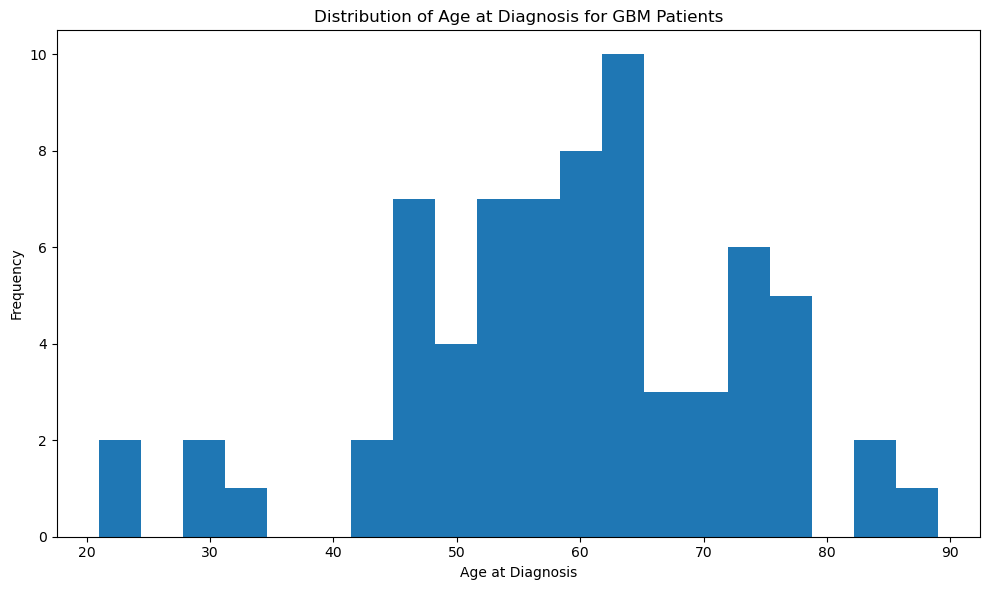

In [436]:
cleaned = GBM_metadata.copy()
cleaned['age_at_diagnosis'] = pd.to_numeric(cleaned['age_at_diagnosis'], errors='coerce')

plt.figure(figsize=(10, 6))
plt.hist(cleaned['age_at_diagnosis'].dropna(), bins=20)
plt.xlabel('Age at Diagnosis')
plt.ylabel('Frequency')
plt.title('Distribution of Age at Diagnosis for GBM Patients')
plt.tight_layout()
plt.show()


In [437]:
scaler = StandardScaler()
X = GBM_data.loc[gene_list].values.T
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
y_age = GBM_metadata['age_at_diagnosis']
valid_indices = y_age.dropna().index
y_age = y_age.loc[valid_indices]
valid_indices = y_age.dropna().index
y_age = y_age.loc[valid_indices]

*Create bins for the different age groups and then plot the PCA using the age groups*

C:\Users\dance\AppData\Local\Temp\ipykernel_28884\1284079006.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GBM_metadata['age_group'] = cleaned.loc[GBM_metadata.index, 'age_group']


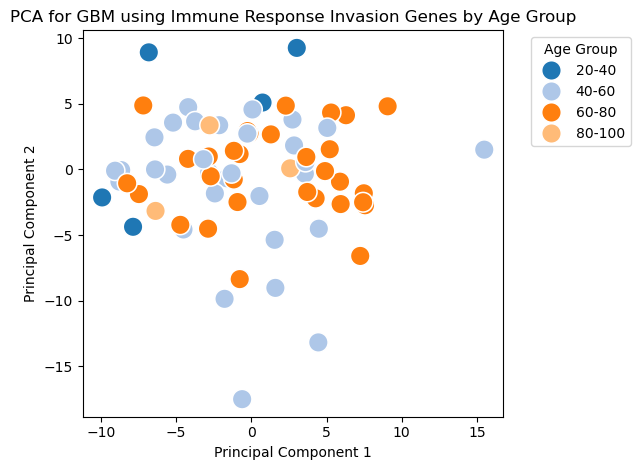

In [438]:
# Create age bins and groups
age_bins = [20, 40, 60, 80, 100]
age_labels = ['20-40', '40-60', '60-80', '80-100']
cleaned = GBM_metadata.copy()
cleaned['age_at_diagnosis'] = pd.to_numeric(cleaned['age_at_diagnosis'], errors='coerce')
cleaned['age_group'] = pd.cut(cleaned['age_at_diagnosis'], bins=age_bins, labels=age_labels, right=False)

# Update GBM_metadata with age groups
GBM_metadata['age_group'] = cleaned.loc[GBM_metadata.index, 'age_group']

# Plot the PCA with age groups as hue
sns.scatterplot(x=X_pca[:, 0], 
                y=X_pca[:, 1], 
                hue=GBM_metadata['age_group'].values,
                palette="tab20", 
                s=200)

plt.title("PCA for GBM using Immune Response Invasion Genes by Age Group")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Age Group")
plt.tight_layout()
plt.show()

*K Means Clustering*

c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dance\AppData\Local\Temp\ipykernel_28884\2014395780.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GBM_metadata.loc[X_with_age.index, 'cluster'] = cluster_labels


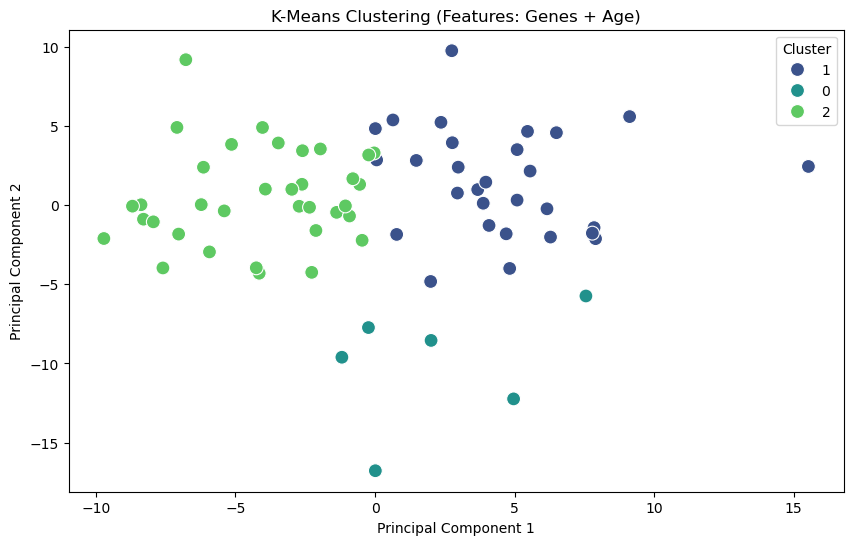

In [439]:
X_genes = GBM_data.loc[gene_list].T
X_with_age = X_genes.copy()
X_with_age['age'] = GBM_metadata.loc[X_with_age.index, 'age_at_diagnosis']
X_with_age = X_with_age.dropna()
filtered_metadata = GBM_metadata.loc[X_with_age.index]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_with_age)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled).astype(str)
GBM_metadata.loc[X_with_age.index, 'cluster'] = cluster_labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=cluster_labels, # This ensures the legend has "artists" to find
    palette='viridis', 
    s=100,
    legend='full'       # Explicitly tells seaborn to build the legend
)
plt.title(f"K-Means Clustering (Features: Genes + Age)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

*Hierarchical Clustering using in-class notebook for a guide*

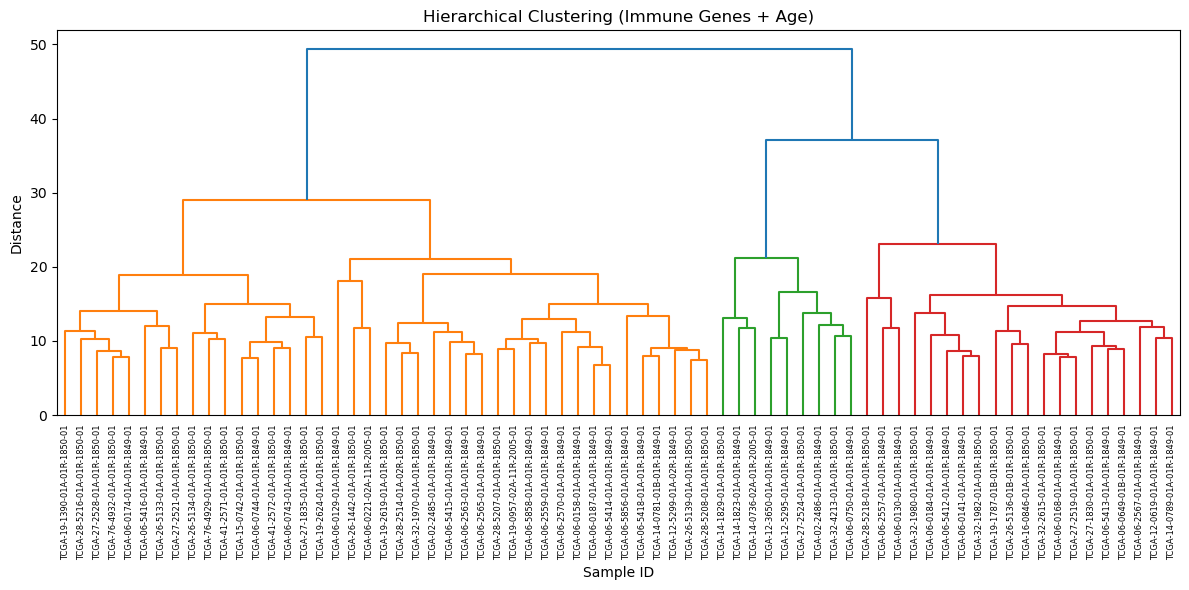

In [440]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X_with_age.index.values)
plt.title("Hierarchical Clustering (Immune Genes + Age)")
plt.xlabel("Sample ID")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Machine Learning Model

We built a linear regression model to help predict gene expression of immune evasion genes based on age. We trained the model on approximately 80% of the specific data acquired from the TRAINING_DATA_SUBSAMPLE and TRAINING_DATA_METADATA for those with GBM, and created a working system that attempts to figure out the gene expression of immune evasion genes when inputting age. The model is validated using the other 20% of the GBM patients since the validation data set did not include patients with GBM. Here's the build:


Model Evaluation (Validation Data):
Gene               R² Interpretation
---------------------------------------------
STAT1         -0.1968  Worse than mean baseline
CXCR4         -0.7198  Worse than mean baseline
PTPN6         -1.8918  Worse than mean baseline
RHOA          -0.8401  Worse than mean baseline
STAT3         -0.5205  Worse than mean baseline
LCK           -0.8191  Worse than mean baseline
CD86          -1.4694  Worse than mean baseline
MAPK14        -0.8811  Worse than mean baseline
HCK           -0.7786  Worse than mean baseline
PTK2          -1.3050  Worse than mean baseline
HIF1A         -0.6408  Worse than mean baseline
PRF1          -1.0452  Worse than mean baseline

Mean Squared Error (MSE):
Gene            MSE Train      MSE Val
----------------------------------------
STAT1              0.3392       0.8490
CXCR4              0.2827       1.6297
PTPN6              0.2303       0.8340
RHOA               0.0231       0.1565
STAT3              0.0957       0.3000
LC

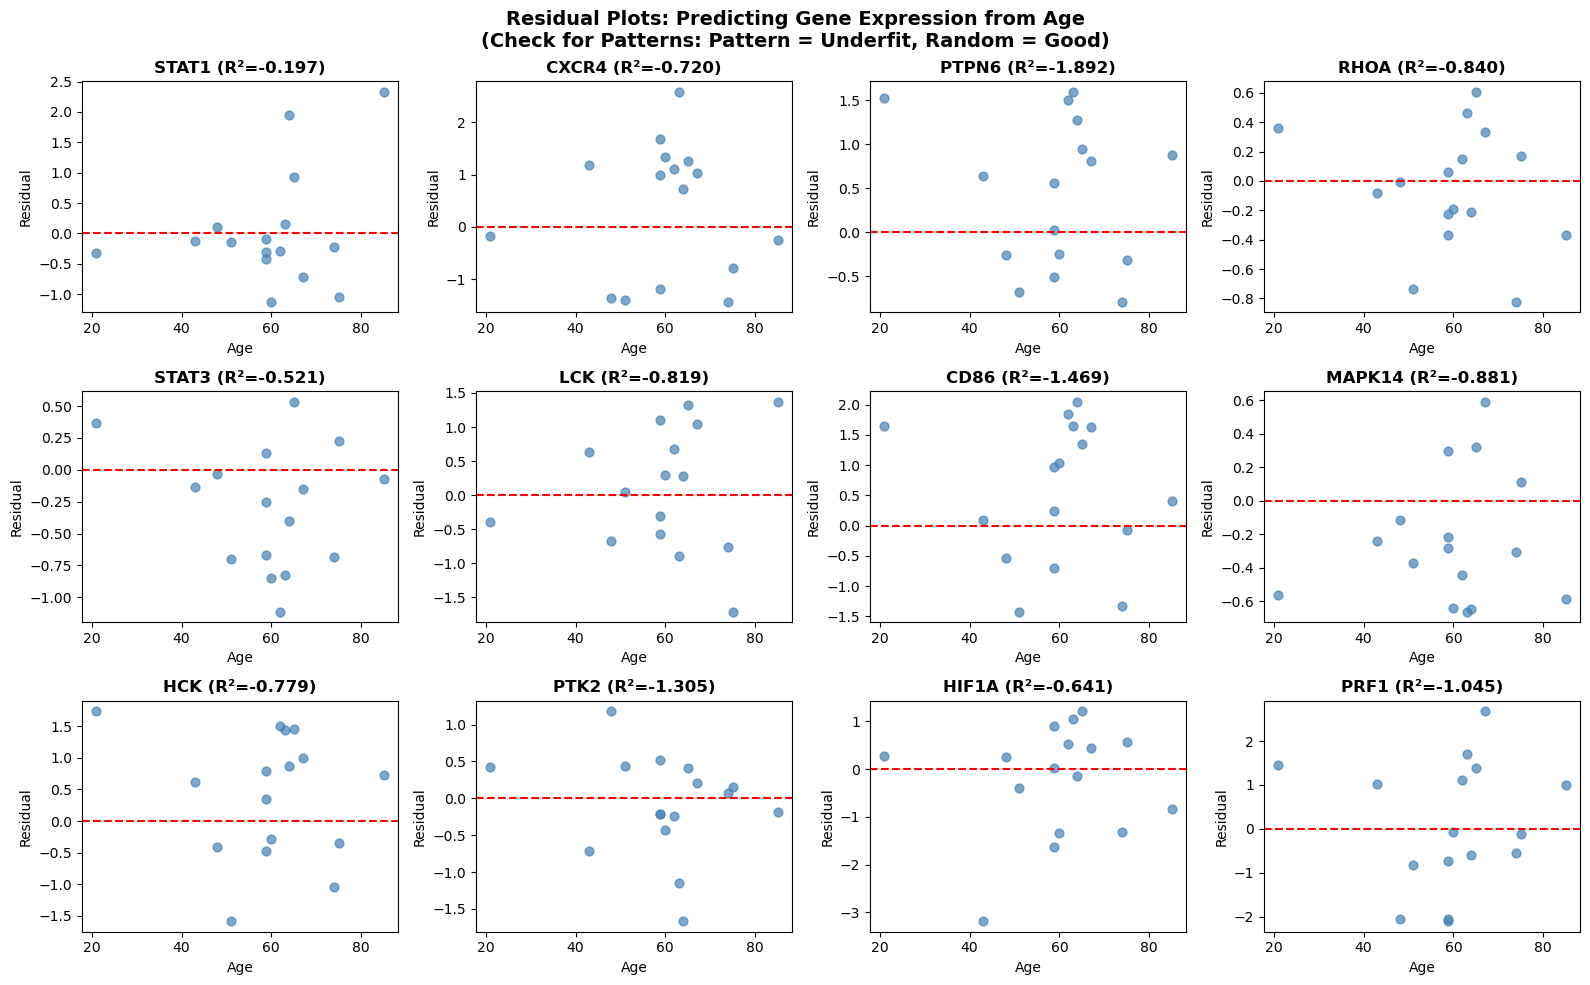


Residual plots saved as residual_plots.png


In [441]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# Get ages for the GBM samples and ensure they match the order of columns in GBM_data
ages = pd.to_numeric(
    GBM_metadata.loc[GBM_data.columns, 'age_at_diagnosis'],
    errors='coerce'
)
ages = ages.fillna(ages.mean()).values
gene_matrix = GBM_data.loc[gene_list].T.values  # Rows: Patients, Cols: Genes

#  Split into Training and Validation sets (using the GBM patients)
# X is Age, y is the Gene Matrix
X_train, X_val, y_train, y_val = train_test_split(ages.reshape(-1, 1), gene_matrix, test_size=0.2, random_state=42)


# We will use the first 12 genes for the 3x4 plot grid
desired_genes = gene_list[:12]
models = {}

for i, gene in enumerate(desired_genes):
    # Train model: Age -> Specific Gene Expression
    model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

    model.fit(X_train, y_train[:, i])
    models[gene] = model

# Model Evaluation and R^2 calculation (Validation Data)
print("\nModel Evaluation (Validation Data):")
print(f"{'Gene':<12} {'R²':>8} {'Interpretation'}")
print("-" * 45)

#plot model

r2_scores = {}
for i, gene in enumerate(desired_genes):
    y_actual = y_val[:, i]
    # Predict using the validation ages
    y_predicted = models[gene].predict(X_val)
    
    r = r2_score(y_actual, y_predicted)
    r2_scores[gene] = r
    
    if r >= 0.7:
        interp = "Good fit"
    elif r >= 0.3:
        interp = "Moderate fit"
    elif r >= 0:
        interp = "Weak fit (likely underfit)"
    else:
        interp = "Worse than mean baseline"
    
    print(f"{gene:<12} {r:>8.4f}  {interp}")

#calculate mean square error for the model for both training and validation data
print("\nMean Squared Error (MSE):")
print(f"{'Gene':<12} {'MSE Train':>12} {'MSE Val':>12}")
print("-" * 40)
for i, gene in enumerate(desired_genes):
    y_train_pred = models[gene].predict(X_train)
    y_val_pred = models[gene].predict(X_val)
    
    mse_train = mean_squared_error(y_train[:, i], y_train_pred)
    mse_val = mean_squared_error(y_val[:, i], y_val_pred)
    
    print(f"{gene:<12} {mse_train:>12.4f} {mse_val:>12.4f}")
    

# Residual Plots
fig2, axes2 = plt.subplots(3, 4, figsize=(16, 10))
axes2 = axes2.flatten()

for i, gene in enumerate(desired_genes):
    ax = axes2[i]
    y_actual = y_val[:, i]
    y_predicted = models[gene].predict(X_val)
    residuals = y_actual - y_predicted

    ax.scatter(X_val, residuals, color='steelblue', alpha=0.7, s=40)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')  # zero line
    ax.set_title(f"{gene} (R²={r2_scores[gene]:.3f})", fontweight='bold')
    ax.set_xlabel('Age')
    ax.set_ylabel('Residual')

plt.suptitle('Residual Plots: Predicting Gene Expression from Age\n(Check for Patterns: Pattern = Underfit, Random = Good)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150)
plt.show()

print("\nResidual plots saved as residual_plots.png")

Necessary notes to make: The validation data did not have any GBM data, so we could not make use of validation data within the system. Instead we trained the model using 80% of the GBM patients, and validated using the remaining 20% of the patients. 

The model did come out to be underfitted by the data due to the predicted values coming out to be on the lower end than what the actual values were, because age isn't the best predictor of gene expression and that there are so many more factors that play into gene expression, so its hard to get a proper value when just using age-based metrics to do so.

For the means of seeing how well the model performed, we used an R^2 for the regression to understand the variance between the data, which in this case is age vs. gene expression. Since age isn't the best predictor of gene expression, and since there are many more variables other than age that checks for gene expression, we expect the values to be low. 


Our original model from check in #3 used all of the patients and did not use a validation set. Our model was improved by filtering to the cancer of interest, and using part of the training set as a validation set to check our model. After, the Linear regression model was not a great fit, so we switched it to the Lasso model which fit the data set a little better. 

We ended with Random Forest Regressor because the lasso model collapsed to a constant due to such a low correlation.

We also had tried training our model using gene expression to predict age, however the model was better for the reverse. It is also more useful in a real life setting to use age to predict gene expression since you will know the patient's age, but not gene expression. 

STAT1- slight overfitting: error higher on validation
HIF1A- too large of a gap: model not a good fit
PTK2- good consitency but negative R^2 means error is still too high relative to the variance
PRF1- better performance on validation than training data- anamoly


Reasons to explain the poor fits: 
-lack of correlation between variables
-data scaling (one gene much higher scale than others can skew model) 


**Using Model for Test Data**

In [442]:
new_data = pd.read_csv(r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\TEST_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)

test_metadata = pd.read_csv(r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TEST_SET_GSE62944_metadata.csv", index_col=0, header=0)


desired_genes = gene_list[:12]
selected_gene = desired_genes[0]
ages = pd.to_numeric(
    test_metadata.loc[new_data.columns, "age_at_diagnosis"],
    errors="coerce"
)
ages = ages.fillna(ages.mean())
X_new = ages.to_numpy().reshape(-1, 1)
final_predictions = models[selected_gene].predict(X_new)

test_metadata.loc[new_data.columns, "Predicted_Gene_Expression"] = final_predictions
print(test_metadata.loc[new_data.columns, ["age_at_diagnosis", "Predicted_Gene_Expression"]].head())
new_data.loc[selected_gene, :] = final_predictions
print(pd.DataFrame({
    "Age": ages.head(),
    "Predicted_Gene_Expression": final_predictions[:5]
}))

                             age_at_diagnosis  Predicted_Gene_Expression
TCGA-E9-A1NH-01A-11R-A14D-07               71                   6.648802
TCGA-E2-A1LH-01A-11R-A14D-07               59                   6.943113
TCGA-BH-A0B0-01A-21R-A115-07               56                   6.237278
TCGA-D8-A73W-01A-22R-A352-07               79                   7.018742
TCGA-LL-A50Y-01A-11R-A266-07               84                   6.571336
                               Age  Predicted_Gene_Expression
TCGA-E9-A1NH-01A-11R-A14D-07  71.0                   6.648802
TCGA-E2-A1LH-01A-11R-A14D-07  59.0                   6.943113
TCGA-BH-A0B0-01A-21R-A115-07  56.0                   6.237278
TCGA-D8-A73W-01A-22R-A352-07  79.0                   7.018742
TCGA-LL-A50Y-01A-11R-A266-07  84.0                   6.571336


In [443]:
#Check the results 
common_samples = new_data.columns.intersection(test_metadata.index)


y_true = new_data.loc[selected_gene, new_data.columns].to_numpy()

test_metadata.loc[new_data.columns, "Predicted_Gene_Expression"] = final_predictions

ages_aligned = pd.to_numeric(
    test_metadata.loc[new_data.columns, 'age_at_diagnosis'],
    errors='coerce'
).fillna(ages.mean())


# PREDICTED values
y_pred = models[selected_gene].predict(X_new)

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Print results
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MSE: 0.0000
RMSE: 0.0000
R^2: 1.0000


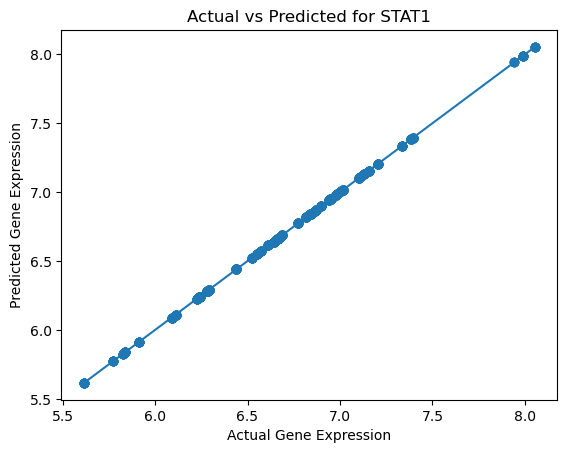

In [444]:
plt.scatter(y_true, y_pred)
plt.xlabel("Actual Gene Expression")
plt.ylabel("Predicted Gene Expression")
plt.title(f"Actual vs Predicted for {selected_gene}")

# reference line (perfect predictions)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()])

In [445]:
comparison_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred,
    "Residual (Error)": y_true - y_pred
})

print(comparison_df.head(10))

     Actual  Predicted  Residual (Error)
0  6.648802   6.648802               0.0
1  6.943113   6.943113               0.0
2  6.237278   6.237278               0.0
3  7.018742   7.018742               0.0
4  6.571336   6.571336               0.0
5  6.089313   6.089313               0.0
6  7.386146   7.386146               0.0
7  7.006417   7.006417               0.0
8  7.104540   7.104540               0.0
9  6.951976   6.951976               0.0


In [446]:
print(type(X))
print(X.shape)
print(X[:2])

<class 'numpy.ndarray'>
(80, 103)
[[ 6.44336706  8.13574145  5.97575153 10.06685668  6.48529281  1.06384143
   5.20780509  4.58577521  6.22217045  5.68950628  7.05581837  4.25535148
   2.00000116  3.23309597  3.62204205  9.32975712  7.08778266  4.883711
   3.73612526  2.966613    5.40042384  5.60324784  6.79765534  5.01139855
   0.34552354  6.33219989  6.13298895  7.18413946  4.74593405  3.21630016
   7.78001733  2.31227627  7.65781091  3.93067498  1.97549091  0.14630445
   3.67129801  1.14867812  2.10710847  4.08892414  6.50712352  5.50942808
   5.31624375  3.30608993  8.0252954   6.26888632  3.2516936   4.54440352
   6.97788686  3.06410194  0.61851376  1.03295442  8.61715276  7.27622042
   0.63684626  4.30535089  2.19260071  3.45522603  5.66357976  6.86501889
   8.08380387  3.06120729  7.39133632  0.56922246  4.41901423 12.88598981
   4.93551893  3.93626158  3.81761041  3.36569431  6.07771566  0.49851424
   1.30556153  0.          5.3214676   8.03969159  4.31160531  3.16924698
   2.8

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 

### Limitations
We faced multiple limitations when building the model:
- Dataset Limitations: The dataset was limited to age at diagnosis, indicating that the cancer onset started at different times. This can skew how the age-based predictions work, because someone who had a later onset can cause data to have smaller values in later ages when later ages are supposed to have higher values.
- Confounding Variables for Immune Evasion: Cancer is complex, even when isolating for 1 hallmark. Immune evasion dictates the ability for a cancer cell to evade immune cells from identifying or recognizing them, which is scattered across 12 genes and has many different ways of manifesting. Every single person who has cancer has different levels of gene activation and progression too, which is the hope that we're trying to fix with this model, but it still provides major variation within the machine learning model.
- Original Testing Complications: 

### Future Work
There are many ways to expand the work to see how much more we can explore GBM and immune evasions.
- Testing out other hallmarks: We're curious in seeing how immune evasion affects other hallmarks and vice versa. The hallmarks that seem most interesting are metabolic reprogramming, angiogenesis, and faster division rate. To create a multimodal model that can see all sorts of relationships in a non-aggressive, aggressive, and adversely aggressive rate, can allow us to see how progression changes over time in many different relationships. This can play in favor to the many different types of ways that cancer progresses in individual, bringing light to models that help doctors see cancer in many different simulations.
- Can cancer develop cancer within itself...? and many other questions - If cancer is its own environment, can't it develop its own form of "cancer"? Essentially, could it have its own form of mutation or change that can have the cancer go back to a healthy cell, or have the cancer become worse, or have the cancer choose specific hallmarks and change to other patterns through how the body changes, or can the cancer induce sepsis whenever it wants? There are a lot of crazy questions that this project opens avenues to, and I feel that machine learning, especially with prediction and simulation systems improving, can give us more insight to every single one of them. 

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*